In [77]:
# ================================================
# Phase 3 — Campaign Response Model
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             classification_report, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Load master data
master = pd.read_csv('../data/master_data.csv')

print("Data loaded!")
print("Shape:", master.shape)
print("\nColumns:", master.columns.tolist())

Data loaded!
Shape: (3834, 12)

Columns: ['CustomerID', 'response', 'n_comp', 'loyalty', 'nps', 'n_communications', 'Total_Spending', 'Purchase_Frequency', 'Recency', 'Unique_Products', 'Avg_Basket_Size', 'nps_group']


In [78]:
# ================================================
# Fix Missing Values
# ================================================

master['nps'] = master['nps'].fillna(master['nps'].median())
master['Total_Spending'] = master['Total_Spending'].fillna(0)
master['Purchase_Frequency'] = master['Purchase_Frequency'].fillna(0)
master['Recency'] = master['Recency'].fillna(999)
master['Unique_Products'] = master['Unique_Products'].fillna(0)
master['Avg_Basket_Size'] = master['Avg_Basket_Size'].fillna(0)

print("Missing values after fix:")
print(master.isnull().sum())

Missing values after fix:
CustomerID            0
response              0
n_comp                0
loyalty               0
nps                   0
n_communications      0
Total_Spending        0
Purchase_Frequency    0
Recency               0
Unique_Products       0
Avg_Basket_Size       0
nps_group             0
dtype: int64


In [79]:
# ================================================
# Prepare Data for Modelling
# ================================================

# independent variables (X)
#  predict (y)

X = master[['Total_Spending', 
            'Purchase_Frequency',
            'Recency',
            'Unique_Products',
            'Avg_Basket_Size',
            'nps',
            'n_comp', 
            'n_communications',
            'loyalty']]

y = master['response']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:", X.columns.tolist())
print("\nResponse distribution:")
print(y.value_counts())
print(f"\nResponse rate: {y.mean()*100:.1f}%")

X shape: (3834, 9)
y shape: (3834,)

Features used: ['Total_Spending', 'Purchase_Frequency', 'Recency', 'Unique_Products', 'Avg_Basket_Size', 'nps', 'n_comp', 'n_communications', 'loyalty']

Response distribution:
response
0    2279
1    1555
Name: count, dtype: int64

Response rate: 40.6%


In [80]:
 # ================================================
#  Split Data Train and Test (80/20)
# ================================================

# Data split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   
    random_state=42,  
    stratify=y       
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print(f"\nTrain response rate: {y_train.mean()*100:.1f}%")
print(f"Test response rate:  {y_test.mean()*100:.1f}%")

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Train size: (3067, 9)
Test size:  (767, 9)

Train response rate: 40.6%
Test response rate:  40.5%


In [81]:
# Create and train the model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)


coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("=== Logistic Regression Coefficients ===")
print(coef_df.to_string(index=False))

=== Logistic Regression Coefficients ===
           Feature  Coefficient
               nps     0.469381
           loyalty     0.294151
  n_communications     0.225292
   Avg_Basket_Size     0.109862
           Recency     0.070189
Purchase_Frequency    -0.005625
   Unique_Products    -0.010112
    Total_Spending    -0.015243
            n_comp    -0.128917


In [82]:
# ================================================
 #  Check Multicollinearity (VIF)
# ================================================


# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(
                    X.values, i) 
                    for i in range(X.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.to_string(index=False))
print("\nRule:")
print("VIF < 5  → No multicollinearity ")
print("VIF 5-10 → Moderate ")
print("VIF > 10 → High multicollinearity")

=== Variance Inflation Factor (VIF) ===
           Feature      VIF
  n_communications 4.789639
               nps 3.434647
            n_comp 3.093679
Purchase_Frequency 3.081835
   Unique_Products 2.640685
           loyalty 2.220277
    Total_Spending 2.041252
           Recency 1.653861
   Avg_Basket_Size 1.495170

Rule:
VIF < 5  → No multicollinearity 
VIF 5-10 → Moderate 
VIF > 10 → High multicollinearity


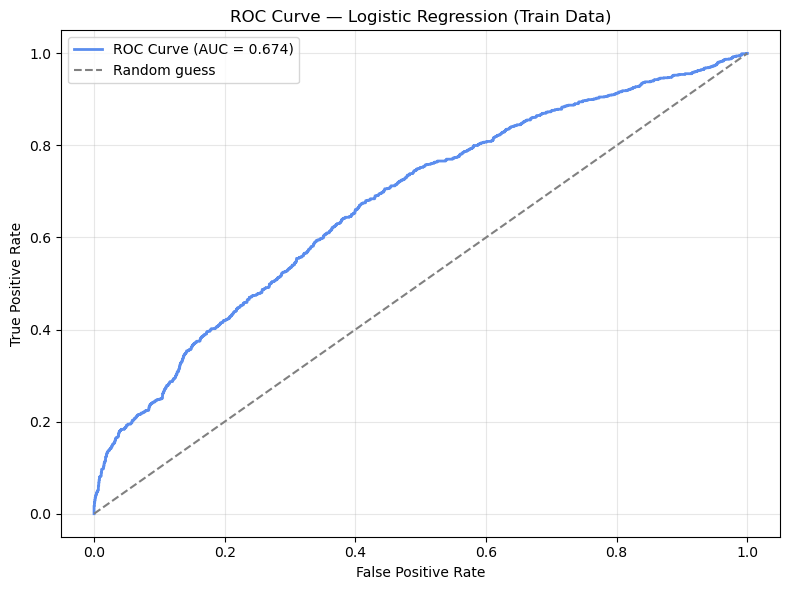

Train AUC: 0.674


In [83]:
# ================================================
# ROC Curve and AUC (Train Data)
# ================================================


# Get predicted probabilities
y_train_prob = log_model.predict_proba(X_train_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)
train_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#5b8dee', linewidth=2,
         label=f'ROC Curve (AUC = {train_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', 
         linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Train Data)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_train.png', dpi=150)
plt.show()

print(f"Train AUC: {train_auc:.3f}")

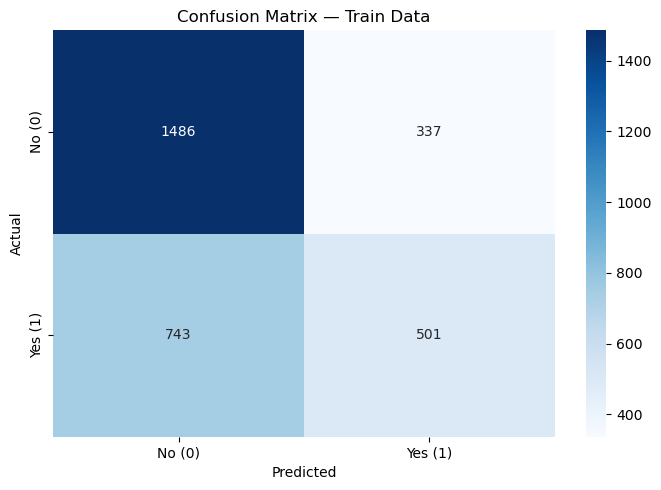

Accuracy:          0.648
Sensitivity:       0.403
Specificity:       0.815
Balanced Accuracy: 0.609


In [84]:
# ================================================
# Confusion Matrix (Train Data)
# ================================================

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import balanced_accuracy_score

# Predict on train data
y_train_pred = log_model.predict(X_train_scaled)

# Confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('Confusion Matrix — Train Data')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_train.png', dpi=150)
plt.show()

# Metrics
tn, fp, fn, tp = cm.ravel()
accuracy     = (tp + tn) / (tp + tn + fp + fn)
sensitivity  = tp / (tp + fn)   
specificity  = tn / (tn + fp)
balanced_acc = balanced_accuracy_score(y_train, y_train_pred)

print(f"Accuracy:          {accuracy:.3f}")
print(f"Sensitivity:       {sensitivity:.3f}")
print(f"Specificity:       {specificity:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")

Best threshold:  0.404
Sensitivity at best threshold: 0.629
Specificity at best threshold: 0.628


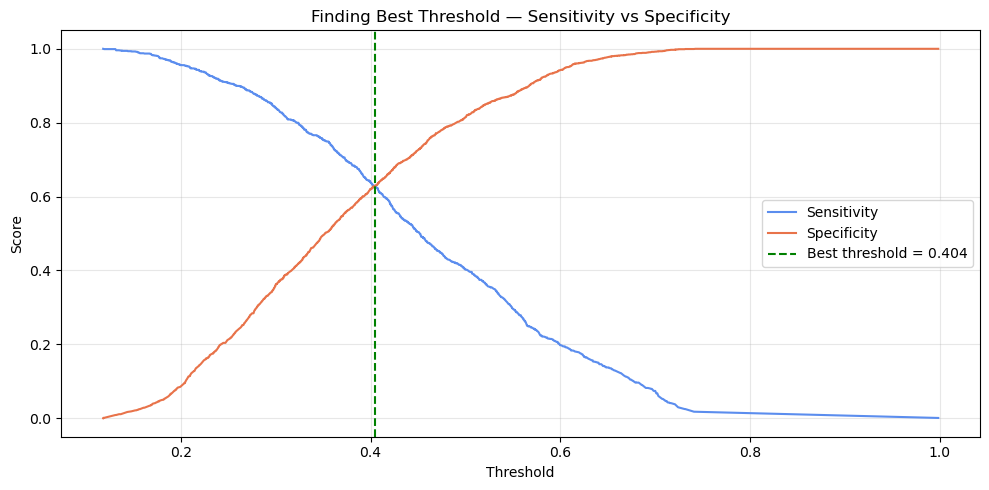

In [85]:
# ================================================
# Find Best Threshold
# ================================================

y_train_prob = log_model.predict_proba(X_train_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)

differences = abs(tpr - (1 - fpr))
best_idx = differences.argmin()
best_threshold = thresholds[best_idx]

print(f"Best threshold:  {best_threshold:.3f}")
print(f"Sensitivity at best threshold: {tpr[best_idx]:.3f}")
print(f"Specificity at best threshold: {1-fpr[best_idx]:.3f}")


plt.figure(figsize=(10, 5))
plt.plot(thresholds, tpr[:-1] if len(tpr) > len(thresholds) 
         else tpr, label='Sensitivity', color='#5b8dee')
plt.plot(thresholds, 
         [1-f for f in fpr[:-1]] if len(fpr) > len(thresholds) 
         else [1-f for f in fpr], 
         label='Specificity', color='#e8734a')
plt.axvline(x=best_threshold, color='green', 
            linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Finding Best Threshold — Sensitivity vs Specificity')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/threshold.png', dpi=150)
plt.show()

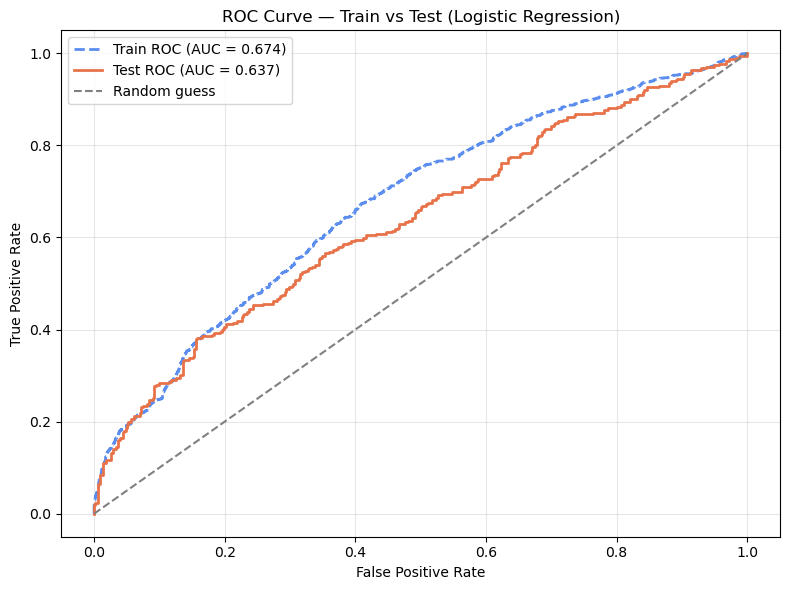

Train AUC: 0.674
Test AUC:  0.637
Difference: 0.037


In [86]:
# ================================================
# ROC Curve and AUC (Test Data)
# ================================================

# Get probabilities for test data
y_test_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve for test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
test_auc = auc(fpr_test, tpr_test)

# Plot both train and test ROC together
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr,
         color='#5b8dee', linewidth=2,
         linestyle='--',
         label=f'Train ROC (AUC = {train_auc:.3f})')
plt.plot(fpr_test, tpr_test,
         color='#e8734a', linewidth=2,
         label=f'Test ROC (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1],
         color='gray', linestyle='--',
         label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Train vs Test (Logistic Regression)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_train_vs_test.png', dpi=150)
plt.show()

print(f"Train AUC: {train_auc:.3f}")
print(f"Test AUC:  {test_auc:.3f}")
print(f"Difference: {abs(train_auc - test_auc):.3f}")

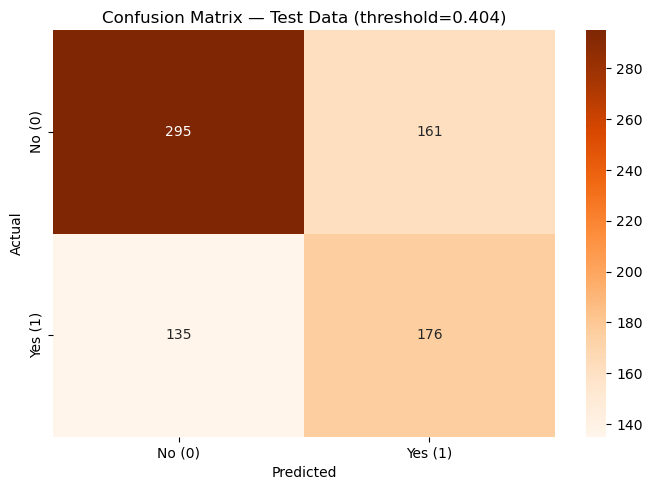

=== Test Data Metrics (at best threshold) ===
Sensitivity:  0.566
Specificity:  0.647

=== Compare Train vs Test ===
Train AUC: 0.674  |  Test AUC:  0.637
Train Sensitivity: 0.403  |  Test Sensitivity: 0.566
Train Specificity: 0.815  |  Test Specificity: 0.647


In [87]:
# ================================================
# Sensitivity and Specificity (Test Data)
# ================================================

# Apply best threshold to test predictions
y_test_pred_best = (y_test_prob >= best_threshold).astype(int)

# Confusion matrix 
cm_test = confusion_matrix(y_test, y_test_pred_best)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d',
            cmap='Oranges',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title(f'Confusion Matrix — Test Data (threshold={best_threshold:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_test.png', dpi=150)
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm_test.ravel()
accuracy_test     = (tp + tn) / (tp + tn + fp + fn)
sensitivity_test  = tp / (tp + fn)
specificity_test  = tn / (tn + fp)

print("=== Test Data Metrics (at best threshold) ===")
print(f"Sensitivity:  {sensitivity_test:.3f}")
print(f"Specificity:  {specificity_test:.3f}")

print("\n=== Compare Train vs Test ===")
print(f"Train AUC: {train_auc:.3f}  |  Test AUC:  {test_auc:.3f}")
print(f"Train Sensitivity: {sensitivity:.3f}  |  Test Sensitivity: {sensitivity_test:.3f}")
print(f"Train Specificity: {specificity:.3f}  |  Test Specificity: {specificity_test:.3f}")

In [88]:
# ================================================
# Phase 4 — Fix Outliers Before ML Models
# ================================================

master_ml = master.copy()

# Fix Recency — replace 999 with median
recency_median = master_ml[master_ml['Recency'] != 999]['Recency'].median()
master_ml['Recency'] = master_ml['Recency'].replace(999, recency_median)

# Cap outliers at 99th percentile
for col in ['Total_Spending', 'Purchase_Frequency', 
            'Unique_Products', 'Avg_Basket_Size']:
    cap = master_ml[col].quantile(0.99)
    master_ml[col] = master_ml[col].clip(upper=cap)
    print(f"{col} capped at: {cap:,.2f}")



Total_Spending capped at: 16,569.92
Purchase_Frequency capped at: 27.34
Unique_Products capped at: 343.35
Avg_Basket_Size capped at: 1,733.85


In [89]:
# ================================================
# Prepare Clean Data for ML Models
# ================================================

X_ml = master_ml[['Total_Spending', 
                   'Purchase_Frequency',
                   'Recency',
                   'Unique_Products',
                   'Avg_Basket_Size',
                   'nps',
                   'n_comp', 
                   'n_communications',
                   'loyalty']]

y_ml = master_ml['response']

# Split 80/20
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml,
    test_size=0.2,
    random_state=42,
    stratify=y_ml
)

# Scale
scaler_ml = StandardScaler()
X_train_ml_scaled = scaler_ml.fit_transform(X_train_ml)
X_test_ml_scaled  = scaler_ml.transform(X_test_ml)
print(f"Train size: {X_train_ml.shape}")
print(f"Test size:  {X_test_ml.shape}")

Train size: (3067, 9)
Test size:  (767, 9)


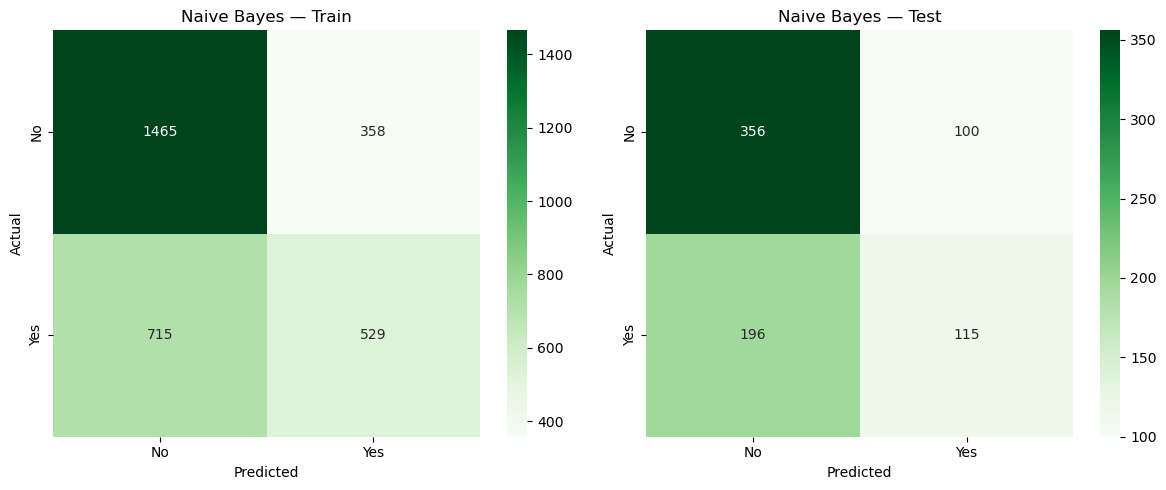

=== Naive Bayes Results ===
Train AUC:         0.683
Test AUC:          0.627
Difference:        0.056
Train Sensitivity: 0.425
Test Sensitivity:  0.370
Train Specificity: 0.804
Test Specificity:  0.781


In [90]:
# ================================================
# Phase 4 — Model 1: Naive Bayes
# ================================================

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_ml_scaled, y_train_ml)

# Train
nb_train_prob = nb_model.predict_proba(X_train_ml_scaled)[:, 1]
nb_train_pred = nb_model.predict(X_train_ml_scaled)
nb_train_auc  = roc_auc_score(y_train_ml, nb_train_prob)
cm_nb_train   = confusion_matrix(y_train_ml, nb_train_pred)
tn, fp, fn, tp = cm_nb_train.ravel()
nb_train_sens = tp / (tp + fn)
nb_train_spec = tn / (tn + fp)

# Test
nb_test_prob = nb_model.predict_proba(X_test_ml_scaled)[:, 1]
nb_test_pred = nb_model.predict(X_test_ml_scaled)
nb_test_auc  = roc_auc_score(y_test_ml, nb_test_prob)
cm_nb_test   = confusion_matrix(y_test_ml, nb_test_pred)
tn, fp, fn, tp = cm_nb_test.ravel()
nb_test_sens = tp / (tp + fn)
nb_test_spec = tn / (tn + fp)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_nb_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[0])
axes[0].set_title('Naive Bayes — Train')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_nb_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[1])
axes[1].set_title('Naive Bayes — Test')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_nb.png', dpi=150)
plt.show()

print("=== Naive Bayes Results ===")
print(f"Train AUC:         {nb_train_auc:.3f}")
print(f"Test AUC:          {nb_test_auc:.3f}")
print(f"Difference:        {abs(nb_train_auc - nb_test_auc):.3f}")
print(f"Train Sensitivity: {nb_train_sens:.3f}")
print(f"Test Sensitivity:  {nb_test_sens:.3f}")
print(f"Train Specificity: {nb_train_spec:.3f}")
print(f"Test Specificity:  {nb_test_spec:.3f}")

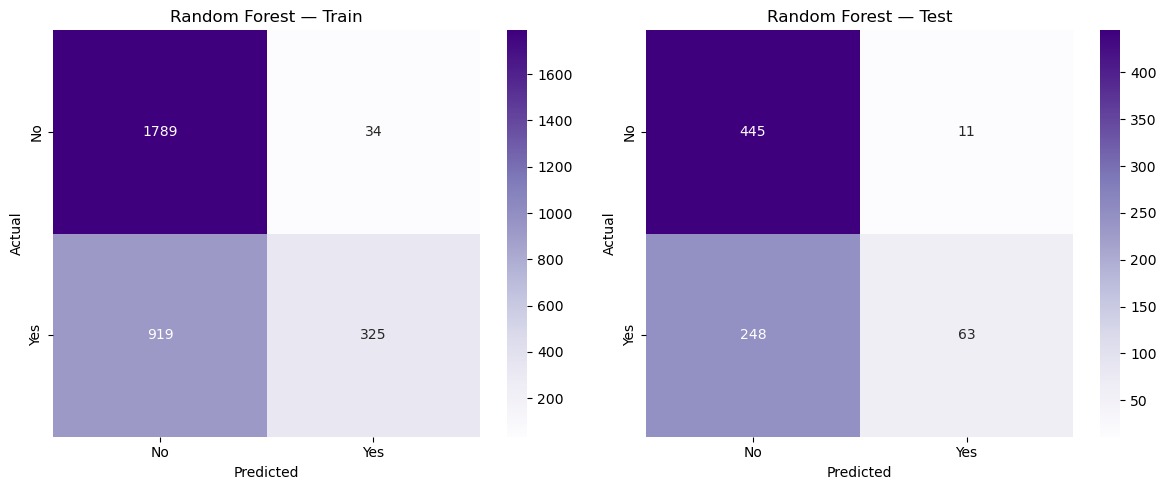

=== Random Forest Results ===
Train AUC:         0.763
Test AUC:          0.668
Difference:        0.095
Train Sensitivity: 0.261
Test Sensitivity:  0.203
Train Specificity: 0.981
Test Specificity:  0.976


In [91]:
# ================================================
# Phase 4 — Model 2: Random Forest
# ================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
rf_model.fit(X_train_ml_scaled, y_train_ml)

# Train
rf_train_prob = rf_model.predict_proba(X_train_ml_scaled)[:, 1]
rf_train_pred = rf_model.predict(X_train_ml_scaled)
rf_train_auc  = roc_auc_score(y_train_ml, rf_train_prob)
cm_rf_train   = confusion_matrix(y_train_ml, rf_train_pred)
tn, fp, fn, tp = cm_rf_train.ravel()
rf_train_sens = tp / (tp + fn)
rf_train_spec = tn / (tn + fp)

# Test
rf_test_prob = rf_model.predict_proba(X_test_ml_scaled)[:, 1]
rf_test_pred = rf_model.predict(X_test_ml_scaled)
rf_test_auc  = roc_auc_score(y_test_ml, rf_test_prob)
cm_rf_test   = confusion_matrix(y_test_ml, rf_test_pred)
tn, fp, fn, tp = cm_rf_test.ravel()
rf_test_sens = tp / (tp + fn)
rf_test_spec = tn / (tn + fp)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rf_train, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[0])
axes[0].set_title('Random Forest — Train')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[1])
axes[1].set_title('Random Forest — Test')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_rf.png', dpi=150)
plt.show()

print("=== Random Forest Results ===")
print(f"Train AUC:         {rf_train_auc:.3f}")
print(f"Test AUC:          {rf_test_auc:.3f}")
print(f"Difference:        {abs(rf_train_auc - rf_test_auc):.3f}")
print(f"Train Sensitivity: {rf_train_sens:.3f}")
print(f"Test Sensitivity:  {rf_test_sens:.3f}")
print(f"Train Specificity: {rf_train_spec:.3f}")
print(f"Test Specificity:  {rf_test_spec:.3f}")

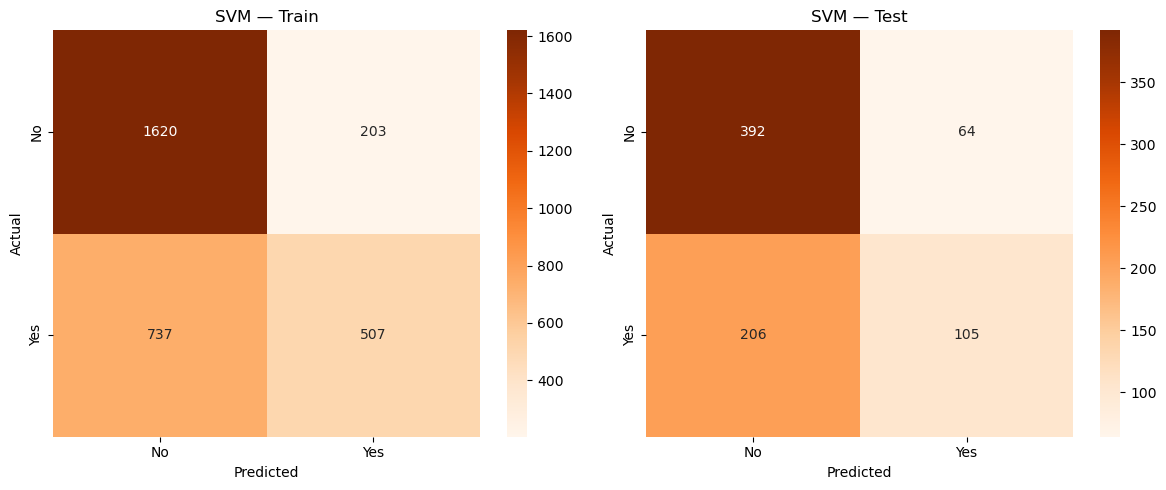

=== SVM Results ===
Train AUC:         0.751
Test AUC:          0.638
Difference:        0.112
Train Sensitivity: 0.408
Test Sensitivity:  0.338
Train Specificity: 0.889
Test Specificity:  0.860


In [92]:
# ================================================
# Phase 4 — Model 3: SVM
# ================================================

from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_ml_scaled, y_train_ml)

# Train
svm_train_prob = svm_model.predict_proba(X_train_ml_scaled)[:, 1]
svm_train_pred = svm_model.predict(X_train_ml_scaled)
svm_train_auc  = roc_auc_score(y_train_ml, svm_train_prob)
cm_svm_train   = confusion_matrix(y_train_ml, svm_train_pred)
tn, fp, fn, tp = cm_svm_train.ravel()
svm_train_sens = tp / (tp + fn)
svm_train_spec = tn / (tn + fp)

# Test
svm_test_prob = svm_model.predict_proba(X_test_ml_scaled)[:, 1]
svm_test_pred = svm_model.predict(X_test_ml_scaled)
svm_test_auc  = roc_auc_score(y_test_ml, svm_test_prob)
cm_svm_test   = confusion_matrix(y_test_ml, svm_test_pred)
tn, fp, fn, tp = cm_svm_test.ravel()
svm_test_sens = tp / (tp + fn)
svm_test_spec = tn / (tn + fp)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_svm_train, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[0])
axes[0].set_title('SVM — Train')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_svm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[1])
axes[1].set_title('SVM — Test')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_svm.png', dpi=150)
plt.show()

print("=== SVM Results ===")
print(f"Train AUC:         {svm_train_auc:.3f}")
print(f"Test AUC:          {svm_test_auc:.3f}")
print(f"Difference:        {abs(svm_train_auc - svm_test_auc):.3f}")
print(f"Train Sensitivity: {svm_train_sens:.3f}")
print(f"Test Sensitivity:  {svm_test_sens:.3f}")
print(f"Train Specificity: {svm_train_spec:.3f}")
print(f"Test Specificity:  {svm_test_spec:.3f}")

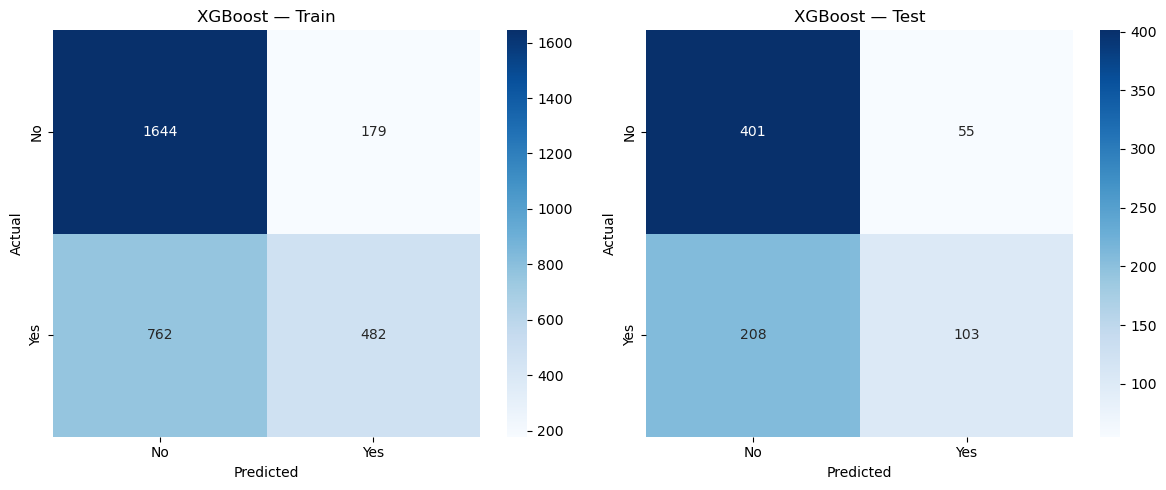

=== XGBoost Results ===
Train AUC:         0.756
Test AUC:          0.661
Difference:        0.094
Train Sensitivity: 0.387
Test Sensitivity:  0.331
Train Specificity: 0.902
Test Specificity:  0.879


In [93]:
# ================================================
# Phase 4 — Model 4: XGBoost
# ================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
   max_depth=2,        
    learning_rate=0.1,  
    subsample=0.5,     
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_ml_scaled, y_train_ml)

# Train
xgb_train_prob = xgb_model.predict_proba(X_train_ml_scaled)[:, 1]
xgb_train_pred = xgb_model.predict(X_train_ml_scaled)
xgb_train_auc  = roc_auc_score(y_train_ml, xgb_train_prob)
cm_xgb_train   = confusion_matrix(y_train_ml, xgb_train_pred)
tn, fp, fn, tp = cm_xgb_train.ravel()
xgb_train_sens = tp / (tp + fn)
xgb_train_spec = tn / (tn + fp)

# Test
xgb_test_prob = xgb_model.predict_proba(X_test_ml_scaled)[:, 1]
xgb_test_pred = xgb_model.predict(X_test_ml_scaled)
xgb_test_auc  = roc_auc_score(y_test_ml, xgb_test_prob)
cm_xgb_test   = confusion_matrix(y_test_ml, xgb_test_pred)
tn, fp, fn, tp = cm_xgb_test.ravel()
xgb_test_sens = tp / (tp + fn)
xgb_test_spec = tn / (tn + fp)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_xgb_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[0])
axes[0].set_title('XGBoost — Train')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_xgb_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=axes[1])
axes[1].set_title('XGBoost — Test')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_xgb.png', dpi=150)
plt.show()

print("=== XGBoost Results ===")
print(f"Train AUC:         {xgb_train_auc:.3f}")
print(f"Test AUC:          {xgb_test_auc:.3f}")
print(f"Difference:        {abs(xgb_train_auc - xgb_test_auc):.3f}")
print(f"Train Sensitivity: {xgb_train_sens:.3f}")
print(f"Test Sensitivity:  {xgb_test_sens:.3f}")
print(f"Train Specificity: {xgb_train_spec:.3f}")
print(f"Test Specificity:  {xgb_test_spec:.3f}")

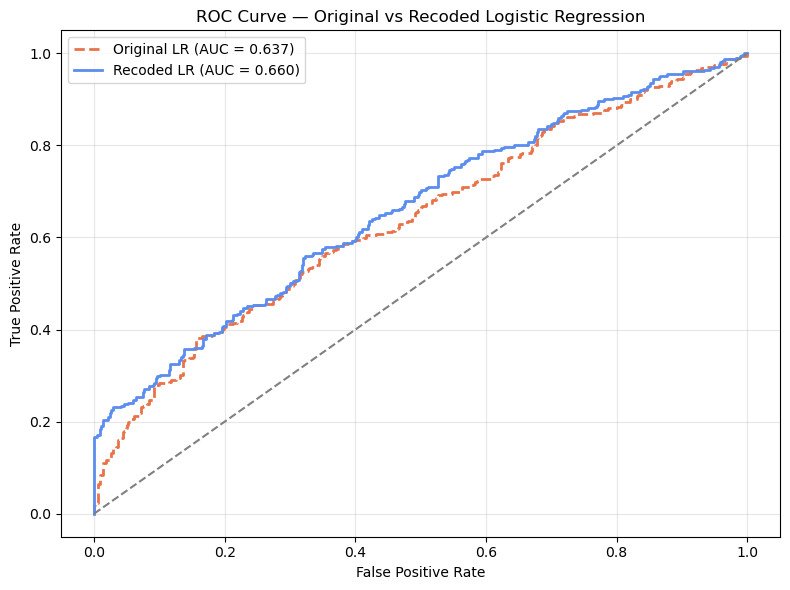

=== Logistic Regression Comparison ===
Original LR  — Train AUC: 0.674  Test AUC: 0.637
Recoded LR   — Train AUC: 0.694  Test AUC: 0.660

✅ Recoded version is BETTER! Use recoded LR


In [94]:
# ================================================
# Phase 3 —  Logistic Regression 
#           with Recoded Variables
# ================================================

# Create recoded version of master data
master_recoded = master.copy()

# Fix missing values first
master_recoded['nps'] = master_recoded['nps'].fillna(master_recoded['nps'].median())
master_recoded['Total_Spending'] = master_recoded['Total_Spending'].fillna(0)
master_recoded['Purchase_Frequency'] = master_recoded['Purchase_Frequency'].fillna(0)
master_recoded['Recency'] = master_recoded['Recency'].fillna(999)
master_recoded['Unique_Products'] = master_recoded['Unique_Products'].fillna(0)
master_recoded['Avg_Basket_Size'] = master_recoded['Avg_Basket_Size'].fillna(0)

# Recode NPS into 3 groups
master_recoded['nps_detractor'] = (master_recoded['nps'] <= 6).astype(int)
master_recoded['nps_passive']   = ((master_recoded['nps'] >= 7) & 
                                   (master_recoded['nps'] <= 8)).astype(int)
master_recoded['nps_promoter']  = (master_recoded['nps'] >= 9).astype(int)

# Use recoded variables instead of raw nps
X_recoded = master_recoded[['Total_Spending',
                             'Purchase_Frequency',
                             'Recency',
                             'Unique_Products',
                             'Avg_Basket_Size',
                             'nps_detractor',
                             'nps_passive',
                             'nps_promoter',
                             'n_comp',
                             'n_communications',
                             'loyalty']]

y_recoded = master_recoded['response']

# Split 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_recoded, y_recoded,
    test_size=0.2,
    random_state=42,
    stratify=y_recoded
)

# Scale
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

# Train Logistic Regression
log_model_r = LogisticRegression(random_state=42, max_iter=1000)
log_model_r.fit(X_train_r_scaled, y_train_r)

# Train results
y_train_r_prob = log_model_r.predict_proba(X_train_r_scaled)[:, 1]
train_auc_r    = roc_auc_score(y_train_r, y_train_r_prob)

# Test results
y_test_r_prob = log_model_r.predict_proba(X_test_r_scaled)[:, 1]
test_auc_r    = roc_auc_score(y_test_r, y_test_r_prob)

# Plot ROC curve
fpr_r, tpr_r, _ = roc_curve(y_test_r, y_test_r_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test,
         color='#e8734a', linewidth=2, linestyle='--',
         label=f'Original LR (AUC = {test_auc:.3f})')
plt.plot(fpr_r, tpr_r,
         color='#5b8dee', linewidth=2,
         label=f'Recoded LR (AUC = {test_auc_r:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Original vs Recoded Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_lr_comparison.png', dpi=150)
plt.show()

print("=== Logistic Regression Comparison ===")
print(f"Original LR  — Train AUC: {train_auc:.3f}  Test AUC: {test_auc:.3f}")
print(f"Recoded LR   — Train AUC: {train_auc_r:.3f}  Test AUC: {test_auc_r:.3f}")

if test_auc_r > test_auc:
    print(f"\n✅ Recoded version is BETTER! Use recoded LR")
else:
    print(f"\n✅ Original version is BETTER! Keep original LR")

=== All Models Comparison ===
                      Model  Train AUC  Test AUC  Difference
        Logistic Regression      0.674     0.637       0.037
Recoded Logistic Regression      0.694     0.660       0.035
                Naive Bayes      0.683     0.627       0.056
              Random Forest      0.763     0.668       0.095
                        SVM      0.751     0.638       0.112
                    XGBoost      0.756     0.661       0.094

 Best model: Random Forest
   Test AUC:   0.668


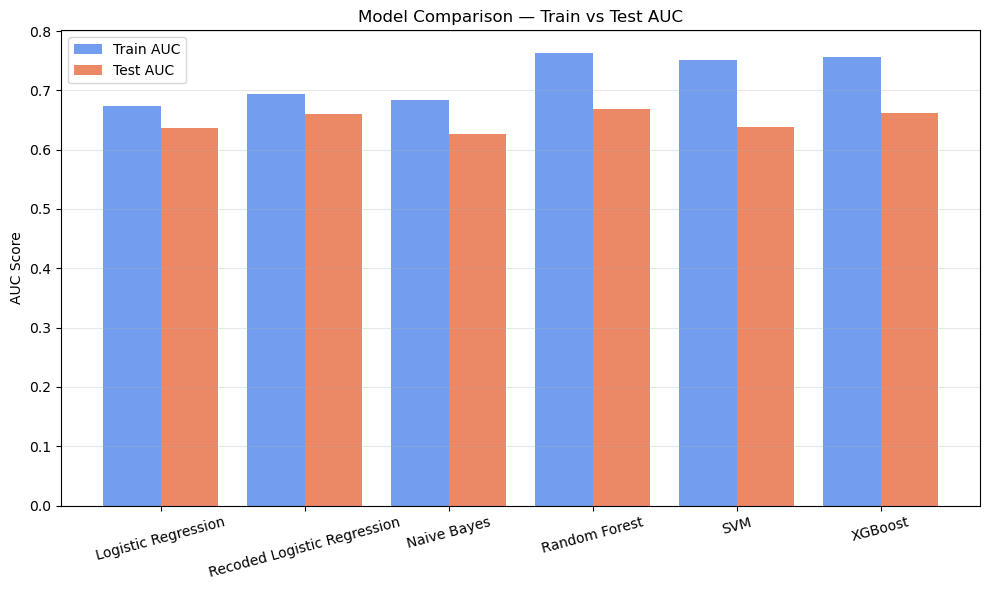

In [95]:
# ================================================
# Phase 4 — Compare All Models
# ================================================

results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Recoded Logistic Regression',
              'Naive Bayes', 
              'Random Forest', 'SVM', 'XGBoost'],
    'Train AUC': [train_auc, train_auc_r,
                  nb_train_auc, rf_train_auc, 
                  svm_train_auc, xgb_train_auc],
    'Test AUC':  [test_auc, test_auc_r,
                  nb_test_auc, rf_test_auc, 
                  svm_test_auc, xgb_test_auc],
})

results['Difference'] = abs(results['Train AUC'] - results['Test AUC'])
results = results.round(3)

print("=== All Models Comparison ===")
print(results.to_string(index=False))
print(f"\n Best model: {results.loc[results['Test AUC'].idxmax(), 'Model']}")
print(f"   Test AUC:   {results['Test AUC'].max():.3f}")

# Plot comparison
plt.figure(figsize=(10, 6))
x = range(len(results))
plt.bar([i - 0.2 for i in x], results['Train AUC'], 
        width=0.4, label='Train AUC', color='#5b8dee', alpha=0.85)
plt.bar([i + 0.2 for i in x], results['Test AUC'],  
        width=0.4, label='Test AUC',  color='#e8734a', alpha=0.85)
plt.xticks(x, results['Model'], rotation=15)
plt.ylabel('AUC Score')
plt.title('Model Comparison — Train vs Test AUC')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150)
plt.show()

In [96]:
# ================================================
# Save Trained Models
# ================================================

import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save Random Forest (best AUC)
joblib.dump(rf_model,    '../models/campaign_model_v1.joblib')
joblib.dump(scaler_ml,   '../models/scaler_v1.joblib')

# Save Recoded Logistic Regression
joblib.dump(log_model_r, '../models/campaign_model_lr_v1.joblib')
joblib.dump(scaler_r,    '../models/scaler_lr_v1.joblib')

print("campaign_model_v1.joblib       ← Random Forest")
print("campaign_model_lr_v1.joblib    ← Recoded LR")

campaign_model_v1.joblib       ← Random Forest
campaign_model_lr_v1.joblib    ← Recoded LR
